# Glaucoma Detection Project - Consolidated Notebook

This notebook is automatically generated from the sub-notebooks:
- 01_preprocessing.ipynb
- 02_segmentation.ipynb
- 03_cdr_calculation.ipynb
- 04_training.ipynb
- 05_evaluation.ipynb
- 06_final_output.ipynb

**Note:** Outputs have been stripped from code cells to reduce file size and avoid redundancy.
To generate outputs, run the notebook cells.

---


# 01 Preprocessing
Use this notebook to validate dataset structure before image preprocessing.

In [1]:
from pathlib import Path

# 1) Expected split/class layout
splits = ["train", "val", "test"]
classes = ["normal", "glaucoma"]
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

# 2) Try common locations so this works regardless of notebook working directory
candidates = [
    Path("dataset"),
    Path("../dataset"),
    Path("glaucoma_project/dataset"),
    Path("../glaucoma_project/dataset"),
]

dataset_root = next((p.resolve() for p in candidates if p.exists()), None)

print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

if dataset_root is None:
    print("No dataset folder found in expected locations.")
    print("Checked:")
    for p in candidates:
        print(f"  - {p.resolve()}")
    print("\nCreate the folder structure first, then run this cell again.")
else:
    print(f"Dataset root: {dataset_root}")

    total_images = 0
    missing_folders = []

    for split in splits:
        print(f"\n{split.upper()}:")
        for cls in classes:
            cls_path = dataset_root / split / cls
            if not cls_path.exists():
                print(f"  {cls:<9} -> MISSING FOLDER")
                missing_folders.append(str(cls_path))
                continue

            files = [f for f in cls_path.iterdir() if f.is_file()]
            image_files = [f for f in files if f.suffix.lower() in valid_ext]
            non_image_count = len(files) - len(image_files)

            print(
                f"  {cls:<9} -> {len(image_files):>5} images"
                + (f"  ({non_image_count} non-image files ignored)" if non_image_count else "")
            )

            total_images += len(image_files)

    print("\n" + "=" * 60)
    print(f"Total images found: {total_images}")

    if missing_folders:
        print("Status: INCOMPLETE")
        print("Missing folders:")
        for folder in missing_folders:
            print(f"  - {folder}")
    elif total_images == 0:
        print("Status: EMPTY DATASET (folders exist, but no valid images found)")
    else:
        print("Status: OK - dataset structure is valid and non-empty")
    print("=" * 60)

DATASET VERIFICATION
Dataset root: C:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project\dataset

TRAIN:
  normal    ->  3936 images
  glaucoma  ->  2366 images

VAL:
  normal    ->   843 images
  glaucoma  ->   507 images

TEST:
  normal    ->   845 images
  glaucoma  ->   508 images

Total images found: 9005
Status: OK - dataset structure is valid and non-empty


## Step 2: Image Preprocessing
This section loads one real fundus image, runs the preprocessing pipeline, and lets you visualize the result before batch processing.

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
src_path = project_root.parent / "src"
if src_path.exists():
    sys.path.insert(0, str(src_path))
else:
    # fallback: add parent directory
    sys.path.insert(0, str(project_root.parent))

from preprocessing import preprocess_image, visualize_preprocessing

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

Sample image: ..\dataset\train\normal\normal_000001.png
Original shape: (746, 746, 3)
Green channel shape: (746, 746)
Normalized range: [0.031, 0.800]
Saved to ..\outputs\plots\preprocessing.png


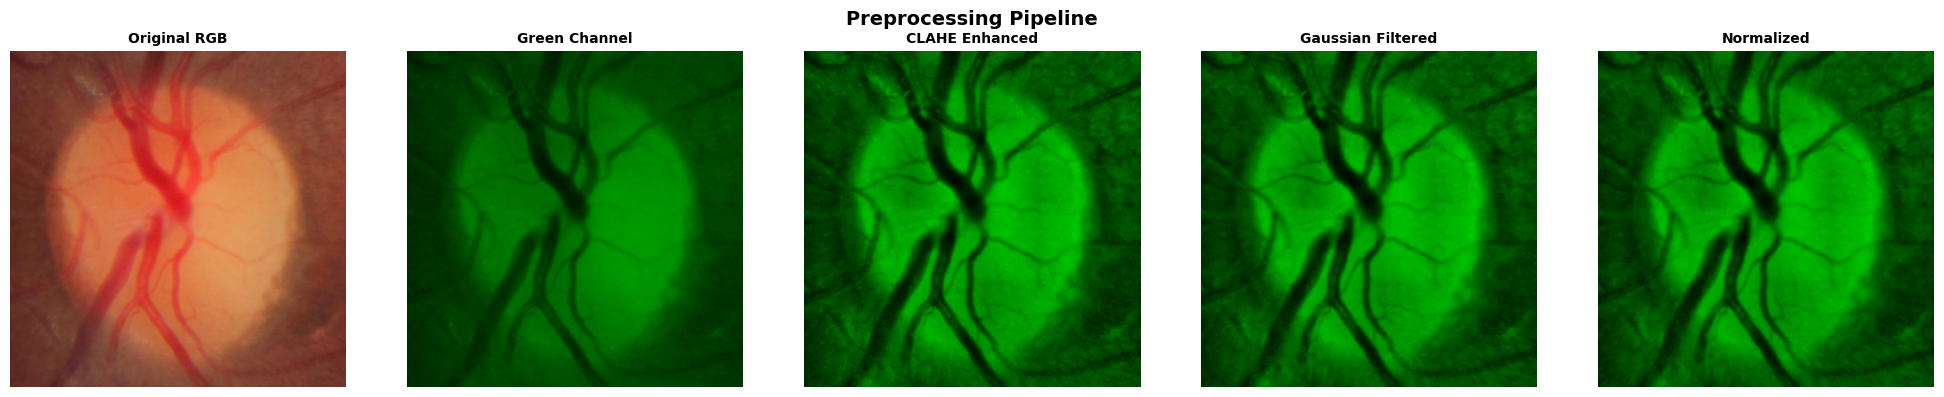

In [3]:
# Pick one real sample image from the dataset
sample_candidates = sorted([p for p in Path("dataset/train/normal").glob("*") if p.suffix.lower() in valid_ext])
if not sample_candidates:
    sample_candidates = sorted([p for p in Path("../dataset/train/normal").glob("*") if p.suffix.lower() in valid_ext])

assert sample_candidates, "No sample images found in dataset/train/normal"

sample_image = sample_candidates[0]
print(f"Sample image: {sample_image}")

results = preprocess_image(str(sample_image), use_clahe=True)
print(f"Original shape: {results['original_rgb'].shape}")
print(f"Green channel shape: {results['green_channel'].shape}")
print(
    f"Normalized range: [{results['normalized'].min():.3f}, {results['normalized'].max():.3f}]"
)

visualize_preprocessing(results, save_path="../outputs/plots/preprocessing.png")

In [4]:
def batch_preprocess_images(input_root, output_root=None, use_clahe=True):
    """Run preprocessing over a folder of images and return a list of results."""
    input_root = Path(input_root)
    valid_ext_local = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    image_paths = sorted([p for p in input_root.rglob("*") if p.is_file() and p.suffix.lower() in valid_ext_local])

    outputs = []
    for image_path in image_paths:
        try:
            result = preprocess_image(str(image_path), use_clahe=use_clahe)
            outputs.append({"path": image_path, "result": result})
            if output_root is not None:
                output_root = Path(output_root)
                output_root.mkdir(parents=True, exist_ok=True)
                save_path = output_root / f"{image_path.stem}_preprocessing.png"
                visualize_preprocessing(result, save_path=str(save_path))
        except Exception as exc:
            print(f"Skipped {image_path.name}: {exc}")

    print(f"Processed {len(outputs)} image(s) from {input_root}")
    return outputs

# 02 Segmentation
Notebook placeholder for segmentation workflow.

# 03 CDR Calculation
Notebook placeholder for cup-to-disc ratio calculations.

# 04 Training
Notebook placeholder for model training experiments.

# 05 Evaluation
Notebook placeholder for model evaluation and metrics.

In [5]:
from pathlib import Path
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

project_root = Path(r'c:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project')
sys.path.insert(0, str(project_root / 'src'))

from dataset import create_dataloaders, CLASS_NAMES
from model import create_resnet50_model

print('Imports loaded successfully.')
print(f'Project root: {project_root}')

Imports loaded successfully.
Project root: c:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project


In [6]:
import os
os.environ['PYTHONIOENCODING'] = 'utf-8'

device = torch.device('cpu')
dataset_root = project_root / 'dataset'
model_path = project_root / 'outputs' / 'models' / 'best_model.pth'

train_loader, val_loader, test_loader, class_weights = create_dataloaders(
    dataset_root=str(dataset_root),
    batch_size=8
)

model = create_resnet50_model(dropout_rate=0.5)

if model_path.exists():
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    print(f'Model loaded from: {model_path}')
else:
    model = None
    print(f'Checkpoint not found: {model_path}')
    print('Run src/train.py first to create the trained model checkpoint.')

print(f'Test batches: {len(test_loader)}')

LOADING DATASETS

📁 Training set:
  Found 3936 images in 'normal/' (label=0)
  Found 2366 images in 'glaucoma/' (label=1)
  Total: 6302 images loaded from c:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project\dataset\train

📁 Validation set:
  Found 843 images in 'normal/' (label=0)
  Found 507 images in 'glaucoma/' (label=1)
  Total: 1350 images loaded from c:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project\dataset\val

📁 Test set:
  Found 845 images in 'normal/' (label=0)
  Found 508 images in 'glaucoma/' (label=1)
  Total: 1353 images loaded from c:\Users\svmoo\OneDrive\Documents\GLAUCOMA\glaucoma_project\dataset\test


⚖️  Computing class weights (for imbalanced REFUGE dataset):
  Class 'normal': 3936 samples, weight = 0.8006
  Class 'glaucoma': 2366 samples, weight = 1.3318

DATALOADER SUMMARY
  Batch size:          8
  Training batches:    788
  Validation batches:  169
  Test batches:        170
  Total train images:  6302
  Total val images:    1350
  Total test 

In [ ]:
def evaluate_model(model, loader, device):
    all_probs = []
    all_labels = []

    if model is None:
        print('Evaluation skipped: model checkpoint is not available yet.')
        return None

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).squeeze(1)
            probs = outputs.detach().cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.numpy().tolist())

    y_true = np.array(all_labels)
    y_prob = np.array(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'report': classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
        'y_true': y_true,
        'y_prob': y_prob,
    }
    return metrics


test_metrics = evaluate_model(model, test_loader, device)
if test_metrics is not None:
    print('Test Accuracy:', round(test_metrics['accuracy'] * 100, 2))
    print('Test Precision:', round(test_metrics['precision'] * 100, 2))
    print('Test Recall:', round(test_metrics['recall'] * 100, 2))
    print('Test F1:', round(test_metrics['f1'] * 100, 2))
    print('Test ROC-AUC:', round(test_metrics['roc_auc'], 4))
    print('\nClassification Report:\n')
    print(test_metrics['report'])

In [ ]:
import seaborn as sns

if test_metrics is not None:
    cm = test_metrics['confusion_matrix']
    y_true = test_metrics['y_true']
    y_prob = test_metrics['y_prob']
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = test_metrics['roc_auc']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[0]
    )
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Plotting skipped because evaluation metrics are not available yet.')

# 06 Final Output
Notebook placeholder for final results and reporting.

## Final Prediction Output

This notebook reproduces the final glaucoma diagnostic panel using the same pipeline as `src/predict.py`.

Using image: glaucoma_002874.jpg
CNN decision threshold: 0.45
Loading pretrained ResNet-50...
✅ Pretrained weights loaded!
🔒 All layers frozen
✅ New classification head added: 2048 → 512 → 1
   Dropout rates: 0.5 (first), 0.3 (second)

ENHANCED K-STRANGE SEGMENTATION

[STAGE 1] Separating Optic Disc from Background...

--- K-Strange Clustering: Disc vs Background ---
  Kmin intensity: 0.2471 (darkest pixel)
  Kmax intensity: 0.7882 (brightest pixel)
  Intensity range: 0.5412
  Cluster 0 (dark/background): 36893 pixels
  Cluster 1 (bright/disc): 3107 pixels
  Refined disc mask with fitted ellipse

[STAGE 2] Separating Optic Cup from Disc Tissue...
  Disc pixels available for Stage 2: 3127
  Disc region Kmin: 0.2941, Kmax: 0.7882
  Cup threshold (65th percentile): 0.6314
  Disc centroid: (85.5, 104.5)

Segmentation complete!
  Disc pixels: 3127
  Cup pixels: 1109


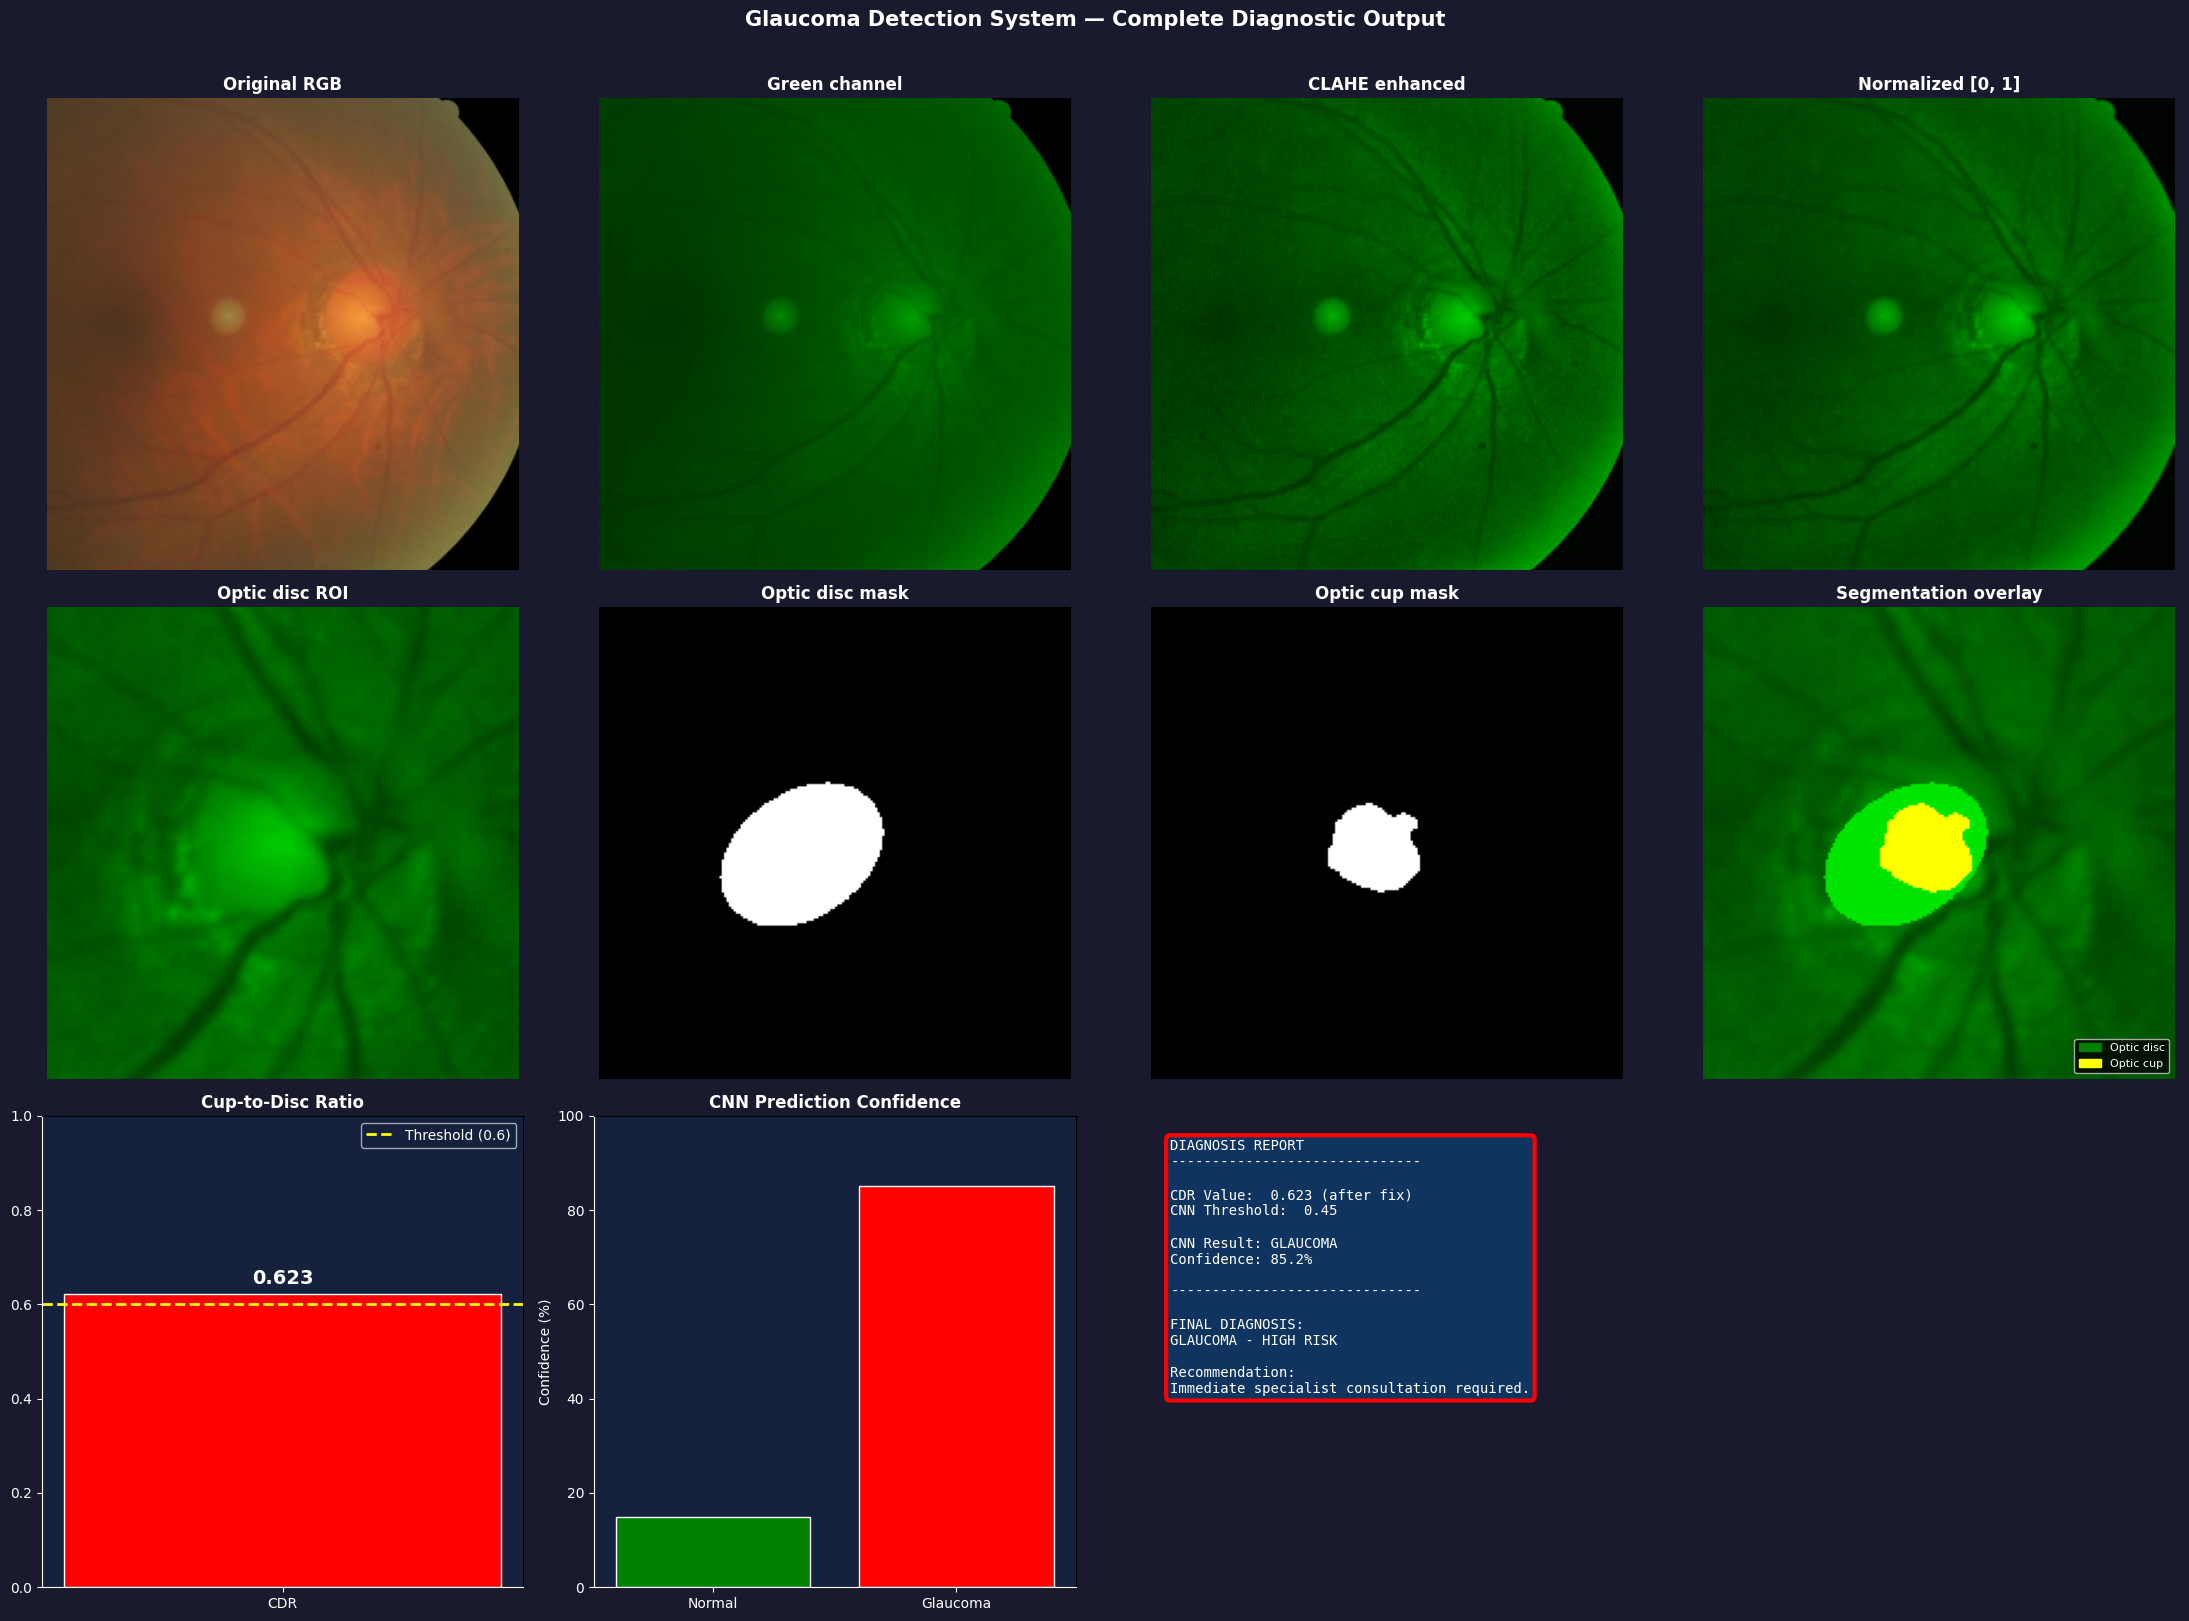

CDR: 0.6230
CNN: GLAUCOMA (85.2%)
Final diagnosis: GLAUCOMA - HIGH RISK
Recommendation: Immediate specialist consultation required.


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

project_root = Path(r"c:/Users/svmoo/OneDrive/Documents/GLAUCOMA/glaucoma_project")
sys.path.insert(0, str(project_root / "src"))

from cdr import compute_cdr, interpret_cdr
from model import create_resnet50_model
from preprocessing import find_first_image, preprocess_image
from segmentation import detect_optic_disc_roi, segment_disc_and_cup


def to_green(gray: np.ndarray) -> np.ndarray:
    """Convert grayscale or float images to green-tinted RGB for display."""
    if gray.dtype != np.uint8:
        img = np.clip(gray * 255.0, 0, 255).astype(np.uint8)
    else:
        img = gray.copy()
    rgb = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    rgb[:, :, 1] = img
    return rgb


predict_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

decision_threshold = 0.45

image_path = find_first_image(project_root / "dataset" / "test" / "glaucoma")
if image_path is None:
    image_path = find_first_image(project_root / "dataset" / "test" / "normal")
if image_path is None:
    raise FileNotFoundError("No test image found in dataset/test/glaucoma or dataset/test/normal.")

model_path = project_root / "outputs" / "models" / "best_model.pth"
device = torch.device("cpu")

print(f"Using image: {image_path.name}")
print(f"CNN decision threshold: {decision_threshold:.2f}")

model = create_resnet50_model()
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

prep_results = preprocess_image(str(image_path), use_clahe=True)
roi, center, bbox = detect_optic_disc_roi(prep_results["normalized"])
disc_mask, cup_mask, _, _ = segment_disc_and_cup(roi)

cup_mask_fixed = (cup_mask.astype(np.uint8) * disc_mask.astype(np.uint8)).astype(np.uint8)

image_pil = Image.open(image_path).convert("RGB")
image_tensor = torch.as_tensor(predict_transform(image_pil))
input_tensor = image_tensor.unsqueeze(0).to(device)
with torch.no_grad():
    probability = float(model(input_tensor).item())
cnn_pred = "GLAUCOMA" if probability >= decision_threshold else "NORMAL"
confidence = probability * 100.0 if cnn_pred == "GLAUCOMA" else (1 - probability) * 100.0

cdr, cdr_details = compute_cdr(disc_mask, cup_mask_fixed)
interpretation = interpret_cdr(cdr)
final = (
    {"label": "GLAUCOMA - HIGH RISK", "color": "red", "recommendation": "Immediate specialist consultation required."}
    if cdr >= 0.6 and cnn_pred == "GLAUCOMA"
    else {"label": "NORMAL", "color": "green", "recommendation": "Routine ophthalmological checkup (annual)."}
    if cdr < 0.6 and cnn_pred == "NORMAL"
    else {
        "label": "BORDERLINE - MANUAL REVIEW NEEDED",
        "color": "orange",
        "recommendation": (
            f"CDR suggests {'Glaucoma' if cdr >= 0.6 else 'Normal'} but CNN predicts {cnn_pred}. "
            f"Please consult an ophthalmologist."
        ),
    }
)

fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("Glaucoma Detection System — Complete Diagnostic Output", fontsize=15, fontweight="bold", color="white", y=1.01)

axes[0, 0].imshow(prep_results["original_rgb"])
axes[0, 0].set_title("Original RGB", color="white", fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(to_green(prep_results["green_channel"]))
axes[0, 1].set_title("Green channel", color="white", fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(to_green(prep_results["clahe_enhanced"]))
axes[0, 2].set_title("CLAHE enhanced", color="white", fontweight="bold")
axes[0, 2].axis("off")

axes[0, 3].imshow(to_green(prep_results["normalized"]))
axes[0, 3].set_title("Normalized [0, 1]", color="white", fontweight="bold")
axes[0, 3].axis("off")

axes[1, 0].imshow(to_green(roi))
axes[1, 0].set_title("Optic disc ROI", color="white", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(disc_mask * 255, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title("Optic disc mask", color="white", fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(cup_mask_fixed * 255, cmap="gray", vmin=0, vmax=255)
axes[1, 2].set_title("Optic cup mask", color="white", fontweight="bold")
axes[1, 2].axis("off")

seg_overlay = np.zeros((*roi.shape, 3), dtype=np.float32)
seg_overlay[:, :, 1] = roi

disc_coords = np.where(disc_mask > 0)
cup_coords = np.where(cup_mask_fixed > 0)
seg_overlay[disc_coords[0], disc_coords[1]] = [0.0, 0.9, 0.0]
seg_overlay[cup_coords[0], cup_coords[1]] = [1.0, 1.0, 0.0]
axes[1, 3].imshow(np.clip(seg_overlay, 0, 1))
disc_patch = mpatches.Patch(color="green", label="Optic disc")
cup_patch = mpatches.Patch(color="yellow", label="Optic cup")
axes[1, 3].legend(handles=[disc_patch, cup_patch], loc="lower right", fontsize=8, facecolor="black", labelcolor="white")
axes[1, 3].set_title("Segmentation overlay", color="white", fontweight="bold")
axes[1, 3].axis("off")

ax5 = axes[2, 0]
ax5.bar(["CDR"], [cdr], color=("red" if cdr >= 0.6 else "green"), width=0.4, edgecolor="white")
ax5.axhline(y=0.6, color="yellow", linestyle="--", linewidth=2, label="Threshold (0.6)")
ax5.set_ylim(0, 1.0)
ax5.set_facecolor("#16213e")
ax5.tick_params(colors="white")
ax5.spines["bottom"].set_color("white")
ax5.spines["left"].set_color("white")
ax5.text(0, cdr + 0.02, f"{cdr:.3f}", ha="center", color="white", fontweight="bold", fontsize=14)
ax5.set_title("Cup-to-Disc Ratio", color="white", fontweight="bold")
ax5.legend(facecolor="#16213e", labelcolor="white")

ax6 = axes[2, 1]
normal_conf = (1 - probability) * 100.0
glaucoma_conf = probability * 100.0
ax6.bar(["Normal", "Glaucoma"], [normal_conf, glaucoma_conf], color=["green", "red"], edgecolor="white")
ax6.set_ylim(0, 100)
ax6.set_facecolor("#16213e")
ax6.tick_params(colors="white")
ax6.spines["bottom"].set_color("white")
ax6.spines["left"].set_color("white")
ax6.set_ylabel("Confidence (%)", color="white")
ax6.set_title("CNN Prediction Confidence", color="white", fontweight="bold")

axes[2, 2].axis("off")
axes[2, 3].axis("off")
report_txt = (
    "DIAGNOSIS REPORT\n"
    + ("-" * 30)
    + "\n\n"
    + f"CDR Value:  {cdr:.3f} (after fix)\n"
    + f"CNN Threshold:  {decision_threshold:.2f}\n\n"
    + f"CNN Result: {cnn_pred}\n"
    + f"Confidence: {confidence:.1f}%\n\n"
    + ("-" * 30)
    + "\n\n"
    + f"FINAL DIAGNOSIS:\n{final['label']}\n\n"
    + f"Recommendation:\n{final['recommendation']}"
)
axes[2, 2].text(
    0.05,
    0.95,
    report_txt,
    transform=axes[2, 2].transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
    color="white",
    bbox=dict(boxstyle="round", facecolor="#0f3460", edgecolor=final["color"], linewidth=3),
)

plt.tight_layout()
plt.show()

print(f"CDR: {cdr:.4f}")
print(f"CNN: {cnn_pred} ({confidence:.1f}%)")
print(f"Final diagnosis: {final['label']}")
print(f"Recommendation: {final['recommendation']}")

In [ ]:
from pathlib import Path
import json

project_root = Path(r"c:/Users/svmoo/OneDrive/Documents/GLAUCOMA/glaucoma_project")
recall_path = project_root / "outputs" / "results" / "tuned_recall_summary.json"
balanced_path = project_root / "outputs" / "results" / "tuned_balanced_summary.json"
baseline_summary_path = project_root / "outputs" / "results" / "resnet_summary.json"

def load_summary(summary_path):
    if not summary_path.exists():
        return None
    with summary_path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

recall_summary = load_summary(recall_path)
balanced_summary = load_summary(balanced_path)

if recall_summary and balanced_summary:
    recall_metrics = recall_summary["test_metrics"]
    recall_tuning = recall_summary["tuning"]
    balanced_metrics = balanced_summary["test_metrics"]
    balanced_tuning = balanced_summary["tuning"]

    print("TUNED RESULTS COMPARISON")
    print("-" * 40)
    print("Recall-first")
    print(f"  Threshold: {recall_tuning['threshold']:.4f}")
    print(f"  Accuracy:  {recall_metrics['accuracy'] * 100:.2f}%")
    print(f"  Precision: {recall_metrics['precision'] * 100:.2f}%")
    print(f"  Recall:    {recall_metrics['recall'] * 100:.2f}%")
    print(f"  F1 Score:  {recall_metrics['f1'] * 100:.2f}%")
    print()
    print("Balanced")
    print(f"  Threshold: {balanced_tuning['threshold']:.4f}")
    print(f"  Accuracy:  {balanced_metrics['accuracy'] * 100:.2f}%")
    print(f"  Precision: {balanced_metrics['precision'] * 100:.2f}%")
    print(f"  Recall:    {balanced_metrics['recall'] * 100:.2f}%")
    print(f"  F1 Score:  {balanced_metrics['f1'] * 100:.2f}%")
    print()
    print("Recommendation: use Balanced for deployment metrics, use Recall-first for screening safety review.")
elif recall_summary:
    recall_metrics = recall_summary["test_metrics"]
    recall_tuning = recall_summary["tuning"]
    print("TUNED EVALUATION SUMMARY")
    print("-" * 40)
    print(f"Threshold:   {recall_tuning['threshold']:.4f}")
    print(f"Accuracy:    {recall_metrics['accuracy'] * 100:.2f}%")
    print(f"Precision:   {recall_metrics['precision'] * 100:.2f}%")
    print(f"Recall:      {recall_metrics['recall'] * 100:.2f}%")
    print(f"F1 Score:    {recall_metrics['f1'] * 100:.2f}%")
    print(f"ROC-AUC:     {recall_metrics['roc_auc']:.4f}")
elif baseline_summary_path.exists():
    with baseline_summary_path.open("r", encoding="utf-8") as handle:
        summary = json.load(handle)
    metrics = summary["performance_metrics"]
    confusion = metrics["confusion_matrix"]
    print("BASELINE SUMMARY")
    print("-" * 40)
    print(f"Accuracy:    {metrics['accuracy'] * 100:.2f}%")
    print(f"Precision:   {metrics['precision'] * 100:.2f}%")
    print(f"Recall:      {metrics['recall'] * 100:.2f}%")
    print(f"F1 Score:    {metrics['f1'] * 100:.2f}%")
    print(f"Specificity: {metrics['specificity'] * 100:.2f}%")
    print()
    print(f"TP: {confusion['TP']} | TN: {confusion['TN']} | FP: {confusion['FP']} | FN: {confusion['FN']}")
    print(f"Mean probability: {summary['mean_probability']:.4f}")
    print(f"High confidence images: {summary['high_confidence_count']}")

TUNED RESULTS COMPARISON
----------------------------------------
Recall-first
  Threshold: 0.2487
  Accuracy:  81.82%
  Precision: 68.61%
  Recall:    95.08%
  F1 Score:  79.70%

Balanced
  Threshold: 0.4742
  Accuracy:  89.28%
  Precision: 87.73%
  Recall:    83.07%
  F1 Score:  85.34%

Recommendation: use Balanced for deployment metrics, use Recall-first for screening safety review.
